# 03 相关性分析与投资组合构建

本 Notebook 完成：
- 5只股票收益率相关性矩阵与热力图
- 两两 60 日滚动相关系数
- 等权重组合绩效评估
- 组合 Beta 与个股 Beta 均值比较
- 选做：有效前沿分析（开关控制）

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
import statsmodels.api as sm
from scipy.optimize import minimize

plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

def setup_chinese_font():
    candidates = ['PingFang SC', 'Heiti SC', 'STHeiti', 'Songti SC', 'Arial Unicode MS', 'Noto Sans CJK SC', 'WenQuanYi Zen Hei', 'SimHei', 'Microsoft YaHei']
    installed = {f.name for f in font_manager.fontManager.ttflist}
    available = [name for name in candidates if name in installed]
    if available:
        plt.rcParams['font.sans-serif'] = available + ['DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

setup_chinese_font()

In [2]:
BASE_DIR = Path.cwd()
CLEAN_DIR = BASE_DIR / 'data_clean'
OUT_DIR = BASE_DIR / 'output'

log_returns = pd.read_csv(CLEAN_DIR / 'log_returns.csv', index_col=0, parse_dates=True)
stock_meta = pd.read_csv(CLEAN_DIR / 'stock_meta.csv', dtype={'symbol': str, 'name': str, 'industry': str})
rf_df = pd.read_csv(CLEAN_DIR / 'risk_free_rate.csv')

RISK_FREE_ANNUAL = float(rf_df.loc[0, 'risk_free_annual'])
RISK_FREE_DAILY = float(rf_df.loc[0, 'risk_free_daily'])
stock_cols = stock_meta['symbol'].str.zfill(6).tolist()

if len(stock_cols) != 5:
    raise ValueError('stock_meta.csv 中股票数量应为 5。')
if 'HS300' not in log_returns.columns:
    raise ValueError('log_returns.csv 缺少 HS300 列。')

stock_returns = log_returns[stock_cols].copy()
market_returns = log_returns['HS300'].copy()

stock_returns.head()

,600036,600519,002475,600276,601088
date,,,,,
2019-01-03,0.011095,-0.014026,-0.049348,-0.036181,-0.002924
2019-01-04,0.022274,0.018700,-0.017777,0.061660,0.013813
2019-01-07,0.000268,0.005375,0.036657,-0.014324,-0.000722
2019-01-08,-0.010486,-0.001076,0.014287,0.007555,0.013279
2019-01-09,0.016797,0.017266,0.005666,0.028057,0.001781


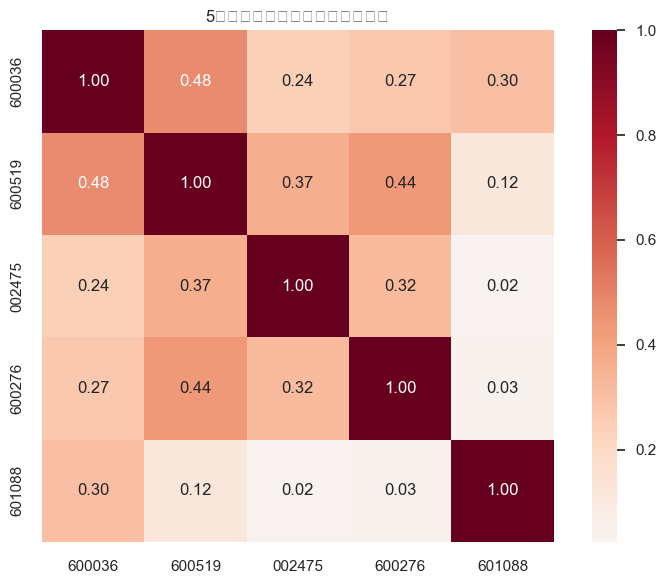

In [3]:
corr_matrix = stock_returns.corr()
corr_matrix.to_csv(OUT_DIR / 'stock_correlation_matrix.csv', encoding='utf-8-sig')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('5只股票日收益率相关系数热力图')
plt.tight_layout()
plt.savefig(OUT_DIR / 'stock_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
window = 60
pair_corr = pd.DataFrame(index=stock_returns.index)

for a, b in combinations(stock_cols, 2):
    name = f'{a}_{b}'
    pair_corr[name] = stock_returns[a].rolling(window).corr(stock_returns[b])

pair_corr.to_csv(OUT_DIR / 'rolling_pair_corr_60d.csv', encoding='utf-8-sig')
pair_corr.tail()

,600036_600519,600036_002475,600036_600276,600036_601088,600519_002475,600519_600276,600519_601088,002475_600276,002475_601088,600276_601088
date,,,,,,,,,,
2026-03-20,0.415207,0.122342,0.257004,0.198369,0.139403,0.492001,-0.094486,0.338750,-0.408525,-0.213224
2026-03-23,0.454148,0.205923,0.356045,0.193868,0.172253,0.518500,-0.084464,0.371215,-0.387825,-0.186685
2026-03-24,0.466189,0.268033,0.396205,0.134015,0.172605,0.512548,-0.082143,0.372796,-0.377559,-0.203342
2026-03-25,0.471288,0.234443,0.416404,0.124307,0.153933,0.514192,-0.082904,0.360611,-0.410458,-0.209467
2026-03-26,0.465628,0.241547,0.398574,0.127732,0.155595,0.513508,-0.083135,0.356673,-0.415463,-0.211049


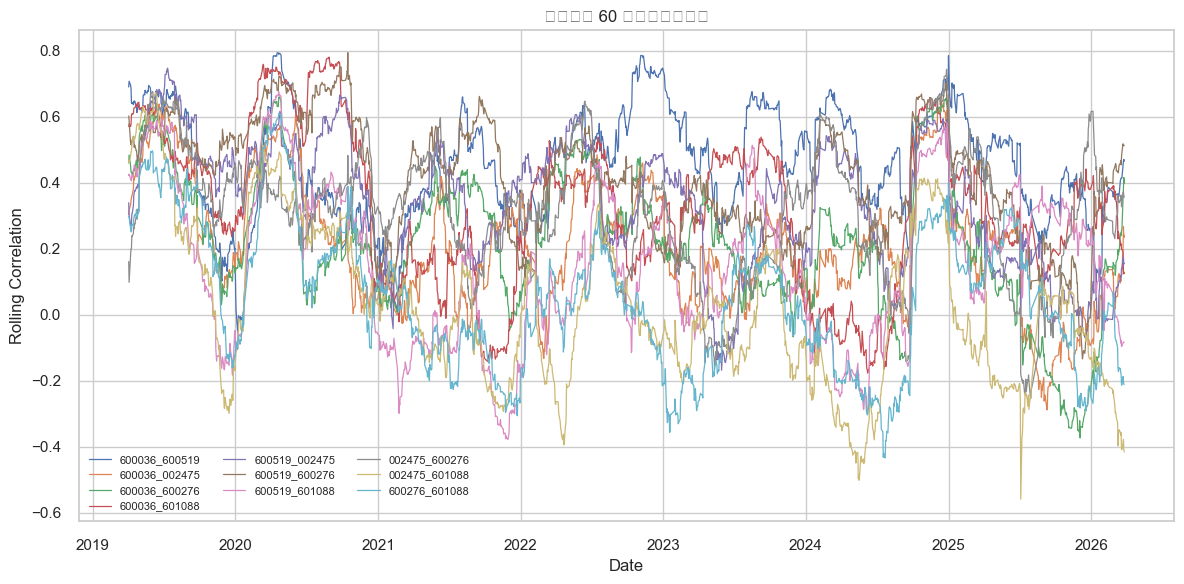

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
for col in pair_corr.columns:
    ax.plot(pair_corr.index, pair_corr[col], linewidth=0.9, label=col)

ax.set_title('股票两两 60 日滚动相关系数')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling Correlation')
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
fig.savefig(OUT_DIR / 'rolling_pair_corr_60d.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
n_assets = len(stock_cols)
weights = np.ones(n_assets) / n_assets

portfolio_returns = stock_returns.dot(weights)
portfolio_df = pd.DataFrame({'portfolio_return': portfolio_returns, 'market_return': market_returns})
portfolio_df.to_csv(OUT_DIR / 'portfolio_daily_returns.csv', encoding='utf-8-sig')

ann_return = portfolio_returns.mean() * 252
ann_vol = portfolio_returns.std(ddof=1) * np.sqrt(252)
sharpe = (ann_return - RISK_FREE_ANNUAL) / ann_vol if ann_vol != 0 else np.nan

portfolio_nav = np.exp(portfolio_returns.cumsum())
market_nav = np.exp(market_returns.cumsum())

running_max = portfolio_nav.cummax()
drawdown = portfolio_nav / running_max - 1
max_drawdown = drawdown.min()

perf_table = pd.DataFrame([{
    'annual_return': ann_return,
    'annual_volatility': ann_vol,
    'max_drawdown': max_drawdown,
    'sharpe_ratio': sharpe
}])
perf_table.to_csv(OUT_DIR / 'portfolio_performance_metrics.csv', index=False, encoding='utf-8-sig')
perf_table

,annual_return,annual_volatility,max_drawdown,sharpe_ratio
0,0.144345,0.191786,-0.350759,0.62228


In [7]:
portfolio_excess = portfolio_returns - RISK_FREE_DAILY
market_excess = market_returns - RISK_FREE_DAILY
reg_data = pd.concat([portfolio_excess, market_excess], axis=1).dropna()
reg_data.columns = ['portfolio_excess', 'market_excess']

model = sm.OLS(reg_data['portfolio_excess'], sm.add_constant(reg_data['market_excess'])).fit()
portfolio_beta = model.params['market_excess']

capm_path = OUT_DIR / 'full_sample_capm.csv'
if capm_path.exists():
    stock_beta_mean = pd.read_csv(capm_path)['beta'].mean()
else:
    stock_beta_mean = np.nan

beta_cmp = pd.DataFrame([{
    'portfolio_beta': portfolio_beta,
    'mean_stock_beta': stock_beta_mean,
    'difference': portfolio_beta - stock_beta_mean if pd.notna(stock_beta_mean) else np.nan
}])
beta_cmp.to_csv(OUT_DIR / 'portfolio_beta_comparison.csv', index=False, encoding='utf-8-sig')
beta_cmp

,portfolio_beta,mean_stock_beta,difference
0,0.838194,0.838194,1.110223e-16


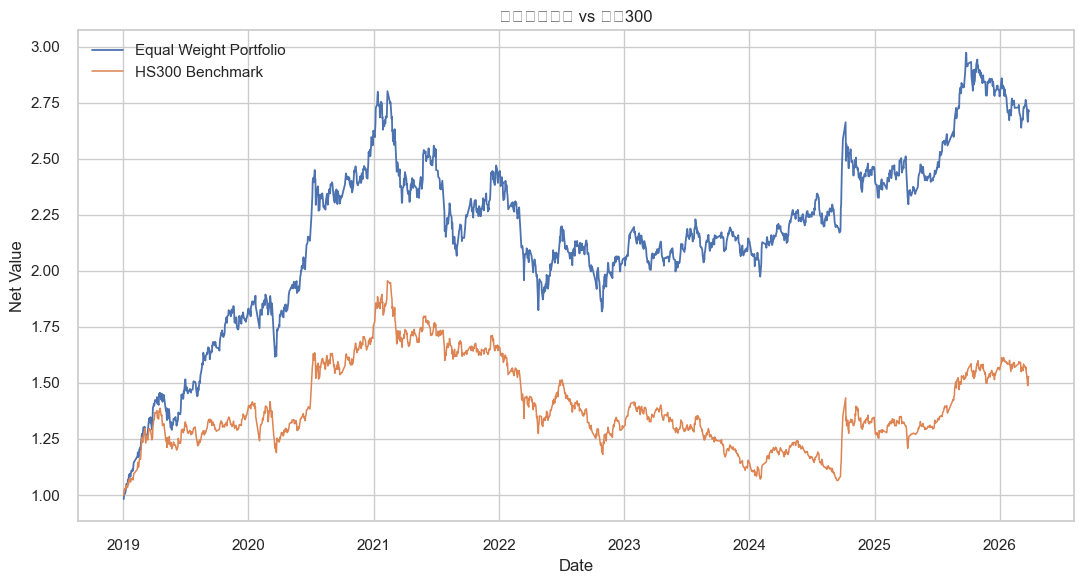

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(portfolio_nav.index, portfolio_nav, label='Equal Weight Portfolio', linewidth=1.3)
ax.plot(market_nav.index, market_nav, label='HS300 Benchmark', linewidth=1.1)
ax.set_title('组合净值曲线 vs 沪深300')
ax.set_xlabel('Date')
ax.set_ylabel('Net Value')
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / 'portfolio_nav_vs_hs300.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
RUN_OPTIONAL_FRONTIER = False

if RUN_OPTIONAL_FRONTIER:
    mu = stock_returns.mean() * 252
    cov = stock_returns.cov() * 252
    n = len(stock_cols)

    def portfolio_stats(w):
        ret = np.dot(w, mu.values)
        vol = np.sqrt(np.dot(w.T, np.dot(cov.values, w)))
        sr = (ret - RISK_FREE_ANNUAL) / vol if vol != 0 else np.nan
        return ret, vol, sr

    bounds = tuple((0, 1) for _ in range(n))
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)

    def min_vol_obj(w):
        return portfolio_stats(w)[1]

    def neg_sharpe_obj(w):
        return -portfolio_stats(w)[2]

    x0 = np.ones(n) / n
    min_var_res = minimize(min_vol_obj, x0=x0, method='SLSQP', bounds=bounds, constraints=cons)
    max_sharpe_res = minimize(neg_sharpe_obj, x0=x0, method='SLSQP', bounds=bounds, constraints=cons)

    random_results = []
    for _ in range(5000):
        w = np.random.random(n)
        w /= w.sum()
        r, v, s = portfolio_stats(w)
        random_results.append({'return': r, 'volatility': v, 'sharpe': s})

    random_df = pd.DataFrame(random_results)

    min_var_w = min_var_res.x
    max_sharpe_w = max_sharpe_res.x
    ew_w = x0

    min_var_pt = portfolio_stats(min_var_w)
    max_sharpe_pt = portfolio_stats(max_sharpe_w)
    ew_pt = portfolio_stats(ew_w)

    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(random_df['volatility'], random_df['return'], c=random_df['sharpe'], cmap='viridis', s=8, alpha=0.6)
    ax.scatter(min_var_pt[1], min_var_pt[0], marker='*', s=250, label='Min Variance')
    ax.scatter(max_sharpe_pt[1], max_sharpe_pt[0], marker='*', s=250, label='Max Sharpe')
    ax.scatter(ew_pt[1], ew_pt[0], marker='o', s=90, label='Equal Weight')
    ax.set_xlabel('Annualized Volatility')
    ax.set_ylabel('Annualized Return')
    ax.set_title('可选：随机组合散点与关键组合')
    ax.legend()
    plt.colorbar(sc, label='Sharpe')
    fig.tight_layout()
    fig.savefig(OUT_DIR / 'optional_efficient_frontier.png', dpi=150, bbox_inches='tight')
    plt.show()

    opt_table = pd.DataFrame([
        {'portfolio': 'min_variance', 'return': min_var_pt[0], 'volatility': min_var_pt[1], 'sharpe': min_var_pt[2]},
        {'portfolio': 'max_sharpe', 'return': max_sharpe_pt[0], 'volatility': max_sharpe_pt[1], 'sharpe': max_sharpe_pt[2]},
        {'portfolio': 'equal_weight', 'return': ew_pt[0], 'volatility': ew_pt[1], 'sharpe': ew_pt[2]}
    ])
    opt_table.to_csv(OUT_DIR / 'optional_frontier_key_portfolios.csv', index=False, encoding='utf-8-sig')

## 分析建议（填写）

- 结合热力图和滚动相关图，讨论市场波动期相关性是否上升。
- 解读组合绩效指标，并说明夏普比率与最大回撤的含义。
- 对 `portfolio_beta_comparison.csv` 结果给出可加性验证结论。
- 如需选做部分，将 `RUN_OPTIONAL_FRONTIER` 设为 `True` 后运行。